<a href="https://colab.research.google.com/github/DinhThanh-Dat/ThucHanhDeepLearning/blob/main/Baitaptuan4_RNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#2. CÀI ĐẶT RNN

##2.1. Nạp thư viện

In [1]:
from pandas import read_csv                            # Nạp hàm đọc file CSV từ thư viện pandas
import numpy as np                                     # Thư viện tính toán toán học và ma trận cấu trúc dữ liệu mảng
from keras.models import Sequential                    # Lớp khởi tạo mô hình mạng nơ-ron theo dạng tuần tự (từng tầng kế tiếp)
from keras.layers import Dense, SimpleRNN              # Dense: Tầng kết nối đầy đủ; SimpleRNN: Tầng RNN cơ bản
from sklearn.preprocessing import MinMaxScaler         # Công cụ chuẩn hóa dữ liệu về đoạn [0, 1]
from sklearn.metrics import mean_squared_error         # Hàm tính toán sai số bình phương trung bình (MSE)
import math                                            # Thư viện toán học tiêu chuẩn của Python (dùng để tính căn bậc hai)
import matplotlib.pyplot as plt                        # Thư viện để vẽ đồ thị kết quả

##2.2. Tạo hàm định nghĩa mô hình RNN

In [4]:
# Số lượng đơn vị ẩn (hidden_units): gồm 2 khối
# Số lượng đơn vị đầu ra (dense_units): gồm 1 khối
# Hình dạng dữ liệu đầu vào (input_shape): (số bước thời gian x số đặc trưng)
# Hàm kích hoạt (activation): tuyến tính f(x) = x
def create_RNN(hidden_units, dense_units, input_shape, activation):
    model = Sequential()                               # Khởi tạo một mô hình mạng nơ-ron tuần tự rỗng

    # Thêm tầng mạng RNN cơ bản vào mô hình với số đơn vị ẩn và hàm kích hoạt được chỉ định
    model.add(SimpleRNN(hidden_units, input_shape=input_shape, activation=activation[0]))

    # Thêm tầng đầu ra kết nối đầy đủ (Dense) để đưa ra dự báo cuối cùng
    model.add(Dense(dense_units, activation=activation[1]))

    # Cấu hình quá trình huấn luyện: sử dụng thuật toán tối ưu 'adam' và hàm mất mát là sai số bình phương trung bình
    model.compile(optimizer='adam', loss='mean_squared_error')

    return model                                       # Trả về đối tượng mô hình sau khi thiết lập xong

# Khởi tạo một mô hình RNN cụ thể: 2 đơn vị ẩn, 1 đầu ra, chuỗi vào gồm 3 bước thời gian (mỗi bước 1 đặc trưng), hàm kích hoạt đều là 'linear'
demo_RNN = create_RNN(2, 1, (3, 1), ['linear', 'linear'])

##2.3. Xem các tham số sinh bởi RNN

In [5]:
wx = demo_RNN.get_weights()[0]     # Trọng số weight kết hợp với đầu vào (inputs) ở tầng recurrent
wh = demo_RNN.get_weights()[1]     # Trọng số weight kết hợp với trạng thái ẩn (hidden state) ở tầng recurrent
bh = demo_RNN.get_weights()[2]     # Trọng số bias kết hợp với tầng recurrent
wy = demo_RNN.get_weights()[3]     # Trọng số weight kết hợp với trạng thái ẩn ở đơn vị đầu ra (output unit)
by = demo_RNN.get_weights()[4]     # Trọng số bias kết hợp với tầng feedforward (tầng đầu ra)

# In các giá trị trọng số và bias ra màn hình để kiểm tra
print('wx=', wx)
print('wh=', wh)
print('bh=', bh)
print('wy=', wy)
print('by=', by)

wx= [[ 0.9535574  -0.07704341]]
wh= [[-0.18093932  0.98349434]
 [-0.98349434 -0.1809392 ]]
bh= [0. 0.]
wy= [[ 1.2861859]
 [-0.6113997]]
by= [0.]


##2.4. Tính vector hidden cho tầng recurrent

In [6]:
x = np.array([1, 2, 3])            # Tạo một mảng dữ liệu đầu vào gồm 3 phần tử đại diện cho 3 bước thời gian

# Thay đổi hình dạng đầu vào thành: kích thước mẫu (1 mẫu) x số bước thời gian (3 bước) x số đặc trưng (1 đặc trưng)
x_input = np.reshape(x, (1, 3, 1))

y_predict_model = demo_RNN.predict(x_input)  # Sử dụng mô hình Keras để dự báo kết quả từ đầu vào x_input

m = 2                              # Khai báo số đơn vị ẩn bằng 2
h0 = np.zeros(m)                   # Khởi tạo vector trạng thái ẩn ban đầu h0 bằng vector 0 (gồm 2 phần tử)

# --- Tính toán thủ công bằng công thức toán học để đối chứng với mô hình ---
# Bước thời gian 1: tính trạng thái ẩn h1 dựa trên đầu vào đầu tiên x[0], trọng số wx, bias bh và h0
h1 = np.dot(x[0], wx) + bh + h0

# Bước thời gian 2: tính trạng thái ẩn h2 dựa trên đầu vào x[1], h1, các trọng số và bias tương ứng
h2 = np.dot(x[1], wx) + np.dot(h1, wh) + bh

# Bước thời gian 3: tính trạng thái ẩn h3 dựa trên đầu vào x[2], h2, các trọng số và bias tương ứng
h3 = np.dot(x[2], wx) + np.dot(h2, wh) + bh

# Bước đầu ra: tính toán giá trị dự báo kết quả cuối cùng o3 dựa vào h3, trọng số wy và bias by
o3 = np.dot(h3, wy) + by

# In kết quả tính toán của các bước ẩn và so sánh kết quả dự báo của mô hình với tính toán thủ công
print('h1:', h1)
print('h2:', h2)
print('h3:', h3)
print('Prediction of model:', y_predict_model)     # Kết quả dự báo từ mô hình Keras
print('Prediction from computation:', o3)          # Kết quả dự báo từ tính toán công thức thủ công

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step
h1: [[ 0.95355737 -0.07704341]]
h2: [[1.81035049 0.79767162]]
h3: [[1.74860301 1.40500915]]
Prediction of model: [[1.390006]]
Prediction from computation: [[1.39000627]]


#3. ÁP DỤNG RNN CHO ỨNG DỤNG THỰC TẾ

##3.1. Đọc dữ liệu

In [10]:
import pandas as pd
# Hàm thực hiện đọc dữ liệu từ URL, chuẩn hóa dữ liệu và chia thành tập huấn luyện (train) và tập kiểm tra (test)
def get_train_test(url, split_percent=0.8):
    # Đọc file CSV, chỉ lấy cột số 2 (chỉ số 1 - cột Sunspots), sử dụng engine phân tích của python
    df = pd.read_csv(url, usecols=[1], engine='python')

    # Chuyển đổi dữ liệu bảng thành mảng Numpy với kiểu dữ liệu số thực float32
    data = np.array(df.values.astype('float32'))

    # Khởi tạo bộ chuẩn hóa để chuyển đổi khoảng giá trị dữ liệu về đoạn từ 0 đến 1
    scaler = MinMaxScaler(feature_range=(0, 1))

    # Tính toán các tham số chuẩn hóa và áp dụng chuyển đổi, sau đó làm phẳng mảng thành mảng 1 chiều
    data = scaler.fit_transform(data).flatten()

    n = len(data)                      # Lấy tổng số dòng dữ liệu
    split = int(n * split_percent)     # Tính toán điểm chia cắt dữ liệu dựa trên tỷ lệ phần trăm (mặc định 80%)

    train_data = data[range(split)]    # Cắt lấy phần dữ liệu đầu làm dữ liệu huấn luyện (từ vị trí 0 đến split-1)
    test_data = data[split:]           # Lấy phần dữ liệu còn lại làm dữ liệu kiểm tra (từ vị trí split đến hết)

    return train_data, test_data, data # Trả về tập train, tập test và toàn bộ mảng dữ liệu đã chuẩn hóa

# Khai báo đường dẫn URL chứa bộ dữ liệu vết đen mặt trời hàng tháng
sunspots_url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/monthly-sunspots.csv'

# Gọi hàm để nhận về các tập dữ liệu phục vụ huấn luyện và kiểm tra
train_data, test_data, data = get_train_test(sunspots_url)

##3.2. Chuẩn bị dữ liệu cho RNN

Chuyển đổi dữ liệu sang total_samples x time_steps x features

Ta đặt time_steps = 2

Hàm get_XY nhận tham số mảng 1 chiều và chuyển thành mảng input X và mục tiêu Y. Sử dụng 12
time_steps để lấy 12 tháng.

In [11]:
# Hàm biến đổi mảng dữ liệu 1 chiều thành các cặp đặc trưng đầu vào X và mục tiêu đầu ra Y dựa theo số bước thời gian
def get_XY(dat, time_steps):
    # Tạo các chỉ số vị trí cho mục tiêu Y (bắt đầu từ vị trí time_steps, nhảy cách quãng bằng time_steps)
    y_ind = np.arange(time_steps, len(dat), time_steps)
    Y = dat[y_ind]                     # Trích xuất các giá trị mục tiêu Y từ mảng dữ liệu

    row_x = len(Y)                     # Số lượng dòng của tập dữ liệu mới

    # Trích xuất các phần tử làm dữ liệu đầu vào X (lấy đủ lượng phần tử tương ứng chuỗi thời gian)
    X = dat[range(time_steps * row_x)]

    # Định hình lại ma trận X thành cấu trúc 3 chiều: số dòng (mẫu) x số bước thời gian x số đặc trưng (1 đặc trưng)
    X = np.reshape(X, (row_x, time_steps, 1))

    return X, Y                        # Trả về ma trận đặc trưng X và vector mục tiêu Y

time_steps = 12                        # Đặt số bước thời gian bằng 12 (tương đương sử dụng dữ liệu chuỗi 12 tháng liên tiếp)
trainX, trainY = get_XY(train_data, time_steps)  # Chuẩn bị tập X, Y cho việc huấn luyện mô hình
testX, testY = get_XY(test_data, time_steps)     # Chuẩn bị tập X, Y cho việc kiểm tra mô hình

##3.3. Tạo RNN model và huấn luyện

In [12]:
# Tạo mô hình mạng RNN với 3 đơn vị ẩn, 1 đơn vị đầu ra, cấu trúc vào (12 bước thời gian, 1 đặc trưng) và hàm kích hoạt 'tanh'
model = create_RNN(hidden_units=3, dense_units=1, input_shape=(time_steps, 1), activation=['tanh', 'tanh'])

# Tiến hành huấn luyện (fit) mô hình trên tập trainX và trainY trong vòng 20 chu kỳ (epochs), hiển thị tiến trình huấn luyện chi tiết (verbose=1)
model_fit = model.fit(trainX, trainY, epochs=20, verbose=1)

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.2037
Epoch 2/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1763 
Epoch 3/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1546 
Epoch 4/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1375 
Epoch 5/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1232 
Epoch 6/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1127 
Epoch 7/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1037 
Epoch 8/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0955 
Epoch 9/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0886 
Epoch 10/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0818
Epoch 11/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0754 
Epoch 12/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0697 
Epoch 13/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0644 
Epoch 14/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0595 
Epoch 15/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0550 
Epoch 16/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/st

##3.4. Hàm tính hiệu quả model
##3.5. Đánh giá kết quả

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
Train RMSE: 0.190 RMSE
Test RMSE: 0.182 RMSE


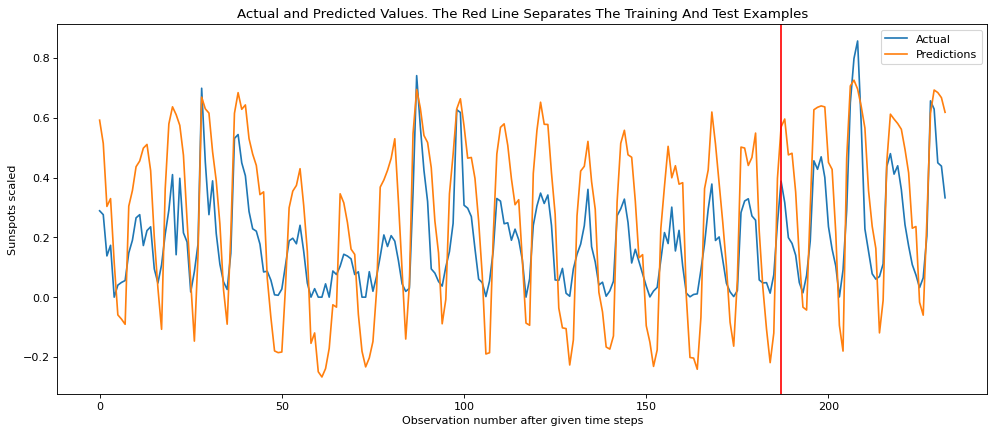

In [13]:
# Định nghĩa hàm tính toán và hiển thị sai số RMSE của mô hình trên hai tập huấn luyện và tập kiểm tra
def print_error(trainY, testY, train_predict, test_predict):
    # Tính toán chỉ số RMSE (Căn bậc hai của sai số bình phương trung bình) cho tập dữ liệu huấn luyện
    train_rmse = math.sqrt(mean_squared_error(trainY, train_predict))

    # Tính toán chỉ số RMSE cho tập dữ liệu kiểm tra
    test_rmse = math.sqrt(mean_squared_error(testY, test_predict))

    # In các giá trị RMSE làm tròn 3 chữ số thập phân ra màn hình
    print('Train RMSE: %.3f RMSE' % (train_rmse))
    print('Test RMSE: %.3f RMSE' % (test_rmse))

# Thực hiện dự báo giá trị trên toàn bộ tập huấn luyện (trainX)
train_predict = model.predict(trainX)

# Thực hiện dự báo giá trị trên toàn bộ tập kiểm tra (testX)
test_predict = model.predict(testX)

# Gọi hàm để in ra sai số của mô hình vừa huấn luyện
print_error(trainY, testY, train_predict, test_predict)

##3.5
# --- Đồ thị hóa kết quả dự báo ---
def plot_result(trainY, testY, train_predict, test_predict):
    actual = np.append(trainY, testY)                 # Ghép nối dữ liệu thực tế của hai tập train và test thành một chuỗi
    predictions = np.append(train_predict, test_predict) # Ghép nối các giá trị dự báo của hai tập train và test thành một chuỗi
    rows = len(actual)                                # Lấy tổng số điểm quan sát dữ liệu

    plt.figure(figsize=(15, 6), dpi=80)               # Khởi tạo khung vẽ đồ thị có kích thước 15x6 inch với độ phân giải 80 dpi
    plt.plot(range(rows), actual)                     # Vẽ đường biểu diễn dữ liệu thực tế (mặc định màu xanh nước biển)
    plt.plot(range(rows), predictions)                # Vẽ đường biểu diễn dữ liệu được dự báo (mặc định màu cam)

    # Vẽ một đường thẳng đứng màu đỏ tại ranh giới kết thúc tập train để phân tách rõ ràng phần huấn luyện và kiểm tra
    plt.axvline(x=len(trainY), color='r')

    plt.legend(['Actual', 'Predictions'])             # Thêm bảng chú giải tên các đường trên đồ thị
    plt.xlabel("Observation number after given time steps") # Gắn nhãn cho trục hoành (Số thứ tự điểm quan sát)
    plt.ylabel('Sunspots scaled')                     # Gắn nhãn cho trục tung (Giá trị lượng vết đen mặt trời đã chuẩn hóa)

    # Đặt tiêu đề cho đồ thị biểu diễn
    plt.title("Actual and Predicted Values. The Red Line Separates The Training And Test Examples")
    plt.show()                                        # Hiển thị đồ thị ra màn hình

# Gọi hàm vẽ đồ thị để trực quan hóa hiệu quả dự báo thực tế của mạng RNN
plot_result(trainY, testY, train_predict, test_predict)